In [1]:
!pip install tf-levenberg-marquardt 

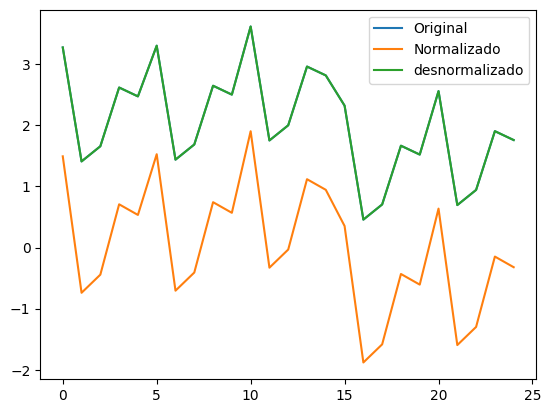

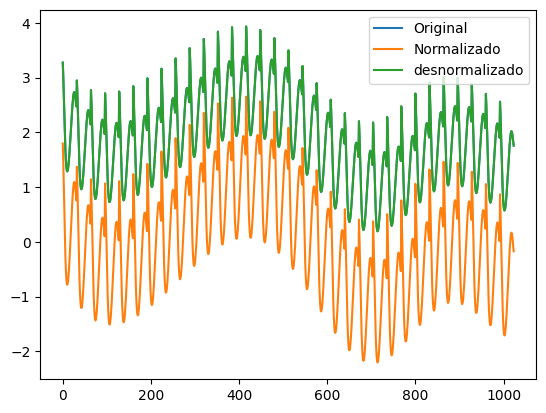

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid): 
    x = np.linspace(1, 0, grid)
    y = np.linspace(1, 0, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-08 15:02:15.405787: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-08 15:02:15.476703: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-08 15:02:15.476749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-08 15:02:15.478291: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-08 15:02:15.487025: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-08 15:02:15.488454: I tensorflow/core/platform/cpu_feature_guard.cc:1

2025-06-08 15:02:16.962249: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[3, 4], [4, 2], [5, 3], [4, 4], [5, 5], [6, 5], [5, 6]],
            regularizers=[0.5, 0.3],
            learning_rate=[0.1, 0.5])

Testando combinacao1: Hidden Size=[3, 4], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_4,0.952851,0.761037,0.971997,0.810193,0.905120,0.027990,0.141859,0.016416,0.104081,0.060248,0.094757,0.167301,1.188596,0.174424,67.151834,103.718109
model_1_0_5,0.953906,0.702453,0.984369,0.753694,0.886436,0.027364,0.176637,0.009163,0.135061,0.072112,0.074316,0.165419,1.184377,0.172462,67.197087,103.763362
model_1_0_6,0.947020,0.688205,0.986534,0.699311,0.863954,0.031451,0.185095,0.007894,0.164883,0.086388,0.069053,0.177345,1.211921,0.184895,66.918623,103.484897
model_1_0_3,0.919253,0.679859,0.923461,0.727182,0.846874,0.047935,0.190049,0.044868,0.149600,0.097234,0.122306,0.218940,1.322987,0.228261,66.075826,102.642101
model_1_0_7,0.942079,0.677149,0.985141,0.661698,0.847071,0.034384,0.191659,0.008711,0.185507,0.097109,0.064983,0.185430,1.231684,0.193325,66.740303,103.306577
model_1_0_8,0.938454,0.669028,0.981885,0.635072,0.834071,0.036537,0.196479,0.010619,0.200108,0.105364,0.067628,0.191146,1.246186,0.199283,66.618881,103.185155
model_1_0_9,0.935220,0.662155,0.977410,0.612811,0.822394,0.038456,0.200559,0.013242,0.212315,0.112778,0.069594,0.196103,1.259121,0.204452,66.516461,103.082736
model_1_0_10,0.932536,0.656767,0.972267,0.595604,0.812590,0.040050,0.203758,0.016257,0.221750,0.119004,0.070930,0.200124,1.269856,0.208644,66.435275,103.001550
model_1_0_11,0.929941,0.651958,0.966600,0.580207,0.803327,0.041590,0.206613,0.019579,0.230193,0.124886,0.072016,0.203936,1.280235,0.212618,66.359795,102.926070
model_1_0_12,0.927692,0.647963,0.960819,0.567877,0.795334,0.042925,0.208984,0.022968,0.236954,0.129961,0.072775,0.207184,1.289233,0.216005,66.296585,102.862860


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [1_1] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_1,0.927761,0.646364,0.934995,0.782925,0.901320,0.042884,0.209934,0.030624,0.047130,0.038877,0.097441,0.207086,1.288958,0.215902,66.298492,102.864766
model_1_1_0,0.924323,0.641853,0.977085,0.827210,0.938688,0.044925,0.212612,0.010795,0.037515,0.024155,0.087252,0.211956,1.302708,0.220979,66.205515,102.771790
model_1_1_2,0.924357,0.641034,0.876400,0.719561,0.848826,0.044905,0.213097,0.058229,0.060888,0.059558,0.107519,0.211908,1.302572,0.220929,66.206416,102.772691
model_1_1_3,0.924940,0.635175,0.840318,0.656414,0.809854,0.044559,0.216576,0.075228,0.074598,0.074913,0.111681,0.211090,1.300242,0.220077,66.221876,102.788150
model_1_1_4,0.927192,0.629676,0.829426,0.612106,0.791133,0.043222,0.219840,0.080359,0.084218,0.082288,0.111310,0.207899,1.291231,0.216749,66.282816,102.849091
model_1_1_5,0.928857,0.624247,0.825533,0.565787,0.776042,0.042233,0.223063,0.082193,0.094274,0.088234,0.109546,0.205508,1.284571,0.214257,66.329087,102.895361
model_1_1_6,0.930160,0.617959,0.825047,0.519215,0.762919,0.041460,0.226796,0.082422,0.104386,0.093404,0.107404,0.203617,1.279359,0.212286,66.366056,102.932331
model_1_1_7,0.930578,0.610106,0.824893,0.467848,0.748673,0.041212,0.231458,0.082494,0.115538,0.099016,0.105547,0.203007,1.277688,0.211649,66.378059,102.944334
model_1_1_8,0.929459,0.600262,0.823056,0.403041,0.729717,0.041876,0.237302,0.083360,0.129609,0.106485,0.104260,0.204637,1.282164,0.213348,66.346079,102.912354
model_1_1_9,0.926208,0.588986,0.818616,0.315068,0.702822,0.043806,0.243996,0.085452,0.148709,0.117080,0.103683,0.209299,1.295167,0.218209,66.255972,102.822247


DataFrame salvo em content/results/metrics_1_1
+++++++++++ [1_2] | 1 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_2] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_2] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 9 +++++++++++

...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_0,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_22,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_21,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_20,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_19,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_18,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_17,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_16,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_15,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_8_14,-4.440892e-16,-6.661338e-16,-0.018585,-3.737212,-0.092247,0.593643,0.593643,1.14433,0.598333,0.871332,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 11ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 13ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 10ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 10ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 9ms/step
+++++++++++ [28_9] |

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_0,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_22,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_21,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_20,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_19,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_18,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_17,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_16,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_15,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751
model_28_9_14,-4.440892e-16,-6.661338e-16,-0.015081,-0.152108,-0.057721,0.593643,0.593643,0.919227,0.694582,0.806905,0.52868,0.770482,1.705882,0.803283,117.042954,187.737751


DataFrame salvo em content/results/metrics_28_9
